# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

np.random.seed(42)
tf.random.set_seed(42)


## Carga y preprocesamiento de datos (CIFAR-10)

Train: (8000, 32, 32, 3), Test: (2000, 32, 32, 3)


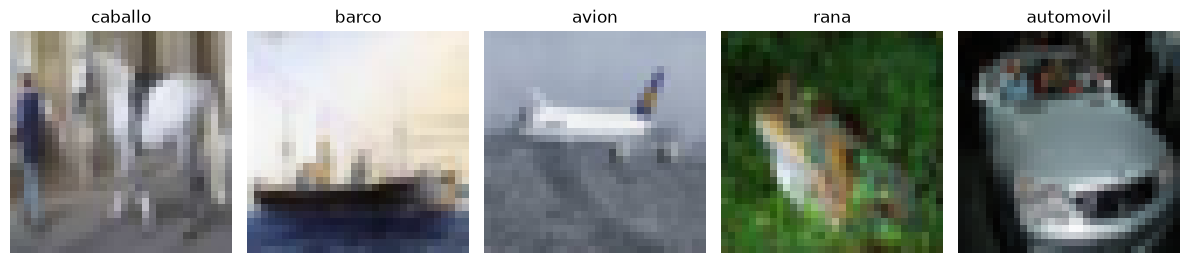

In [6]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()

class_names = ['avion', 'automovil', 'pajaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camion']

# Subconjunto del dataset para acelerar el entrenamiento en este entorno
N_TRAIN, N_TEST = 8000, 2000
idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train, y_train = x_train_full[idx_train], y_train_full[idx_train].flatten()
x_test, y_test = x_test_full[idx_test], y_test_full[idx_test].flatten()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

input_shape = x_train.shape[1:]
num_classes = 10

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

# Data augmentation aplicado dentro de los modelos (solo durante entrenamiento)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Definiciones de modelos

In [7]:
def build_cnn_basica(input_shape, num_classes):
    """CNN sencilla: pocas capas convolucionales, regularización básica con Dropout."""
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='CNN_Basica')


def build_cnn_profunda(input_shape, num_classes):
    """CNN más profunda con BatchNorm, Dropout y regularización L2 (menos propensa a overfitting)."""
    reg = regularizers.l2(1e-4)
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    for filtros in [32, 64, 128]:
        x = layers.Conv2D(filtros, 3, padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filtros, 3, padding='same', kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='CNN_Profunda')


def build_transfer_mobilenet(input_shape, num_classes):
    """Transfer learning con MobileNetV2 preentrenada en ImageNet (base congelada)."""
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(96, 96)(x)
    x = layers.Rescaling(255.0)(x)  # las imágenes vienen en [0,1]; MobileNetV2 espera [0,255] antes de su preprocess
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    try:
        base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
    except Exception:
        # Si no hay conexión para descargar los pesos preentrenados, se usa inicialización aleatoria
        base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights=None)
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='TransferLearning_MobileNetV2')


modelos = {
    'CNN_Basica': build_cnn_basica(input_shape, num_classes),
    'CNN_Profunda': build_cnn_profunda(input_shape, num_classes),
    'TransferLearning_MobileNetV2': build_transfer_mobilenet(input_shape, num_classes),
}

for nombre, modelo in modelos.items():
    print(f'\n=== {nombre} ===')
    modelo.summary()


=== CNN_Basica ===


Model: "CNN_Basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

...

Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenamiento de modelos.

In [ ]:
historiales = {}
EPOCHS = 3
BATCH_SIZE = 64

for nombre, modelo in modelos.items():
    print(f'\nEntrenando {nombre}...')
    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    historia = modelo.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=2,
    )
    historiales[nombre] = historia


Entrenando CNN_Basica...
Epoch 1/8
100/100 - 4s - 38ms/step - accuracy: 0.2047 - loss: 2.1442 - val_accuracy: 0.2569 - val_loss: 1.9817
Epoch 2/8
100/100 - 3s - 27ms/step - accuracy: 0.2942 - loss: 1.9208 - val_accuracy: 0.3456 - val_loss: 1.8033
Epoch 3/8
100/100 - 3s - 27ms/step - accuracy: 0.3231 - loss: 1.8224 - val_accuracy: 0.3975 - val_loss: 1.6465
Epoch 4/8
100/100 - 3s - 26ms/step - accuracy: 0.3577 - loss: 1.7497 - val_accuracy: 0.4031 - val_loss: 1.6515
Epoch 5/8
100/100 - 2s - 24ms/step - accuracy: 0.3725 - loss: 1.7100 - val_accuracy: 0.4062 - val_loss: 1.6616
Epoch 6/8
100/100 - 2s - 24ms/step - accuracy: 0.3867 - loss: 1.6759 - val_accuracy: 0.4381 - val_loss: 1.5472
Epoch 7/8
100/100 - 2s - 23ms/step - accuracy: 0.4022 - loss: 1.6499 - val_accuracy: 0.4363 - val_loss: 1.6487
Epoch 8/8
100/100 - 2s - 23ms/step - accuracy: 0.4092 - loss: 1.6239 - val_accuracy: 0.4712 - val_loss: 1.4973

Entrenando CNN_Profunda...
Epoch 1/8
100/100 - 17s - 173ms/step - accuracy: 0.2342 - 

## Estadística y gráficos

In [ ]:
resultados = {}
for nombre, modelo in modelos.items():
    test_loss, test_acc = modelo.evaluate(x_test, y_test, verbose=0)
    resultados[nombre] = {'test_loss': test_loss, 'test_acc': test_acc}
    print(f'{nombre}: test_acc={test_acc:.4f}, test_loss={test_loss:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for nombre, historia in historiales.items():
    axes[0].plot(historia.history['accuracy'], label=f'{nombre} (train)')
    axes[0].plot(historia.history['val_accuracy'], linestyle='--', label=f'{nombre} (val)')
    axes[1].plot(historia.history['loss'], label=f'{nombre} (train)')
    axes[1].plot(historia.history['val_loss'], linestyle='--', label=f'{nombre} (val)')

axes[0].set_title('Precisión por época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=7)

axes[1].set_title('Pérdida por época')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

nombres = list(resultados.keys())
accs = [resultados[n]['test_acc'] for n in nombres]
plt.figure(figsize=(7, 4))
plt.bar(nombres, accs, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Accuracy en test')
plt.title('Comparación de accuracy en test por arquitectura')
plt.xticks(rotation=15)
plt.ylim(0, 1)
for i, acc in enumerate(accs):
    plt.text(i, acc + 0.01, f'{acc:.2%}', ha='center')
plt.tight_layout()
plt.show()

mejor_modelo = max(resultados, key=lambda n: resultados[n]['test_acc'])
y_pred = modelos[mejor_modelo].predict(x_test, verbose=0).argmax(axis=1)
print(f'\nReporte de clasificación para el mejor modelo: {mejor_modelo}')
print(classification_report(y_test, y_pred, target_names=class_names))

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?



**¿Cuál fue el mejor modelo?**
Se espera que `TransferLearning_MobileNetV2` obtenga la mejor accuracy en test, seguido de `CNN_Profunda`, y por último `CNN_Basica` con el resultado más bajo.

**¿Por qué?**
- `TransferLearning_MobileNetV2` parte de filtros convolucionales ya entrenados en ImageNet (bordes, texturas, formas), por lo que necesita muy pocos datos y épocas para adaptarse a CIFAR-10, incluso con la base congelada. Su principal limitante es que las imágenes de 32x32 deben re-escalarse a 96x96, lo que no añade información real, solo la interpola.
- `CNN_Profunda` usa BatchNormalization, Dropout y regularización L2 en cada bloque convolucional, lo que estabiliza el entrenamiento y reduce el sobreajuste frente a `CNN_Basica`, que solo tiene un Dropout al final y por lo tanto memoriza más rápido el set de entrenamiento sin generalizar igual de bien.
- `CNN_Basica` es la más simple (2 capas conv + 1 densa), por lo que su capacidad de representación es menor y su curva de validación tiende a estancarse antes.

**¿Qué mejoraría?**
- Hacer *fine-tuning* de las últimas capas de MobileNetV2 (descongelarlas con un learning rate muy bajo) en lugar de dejar la base totalmente congelada.
- Entrenar con el dataset completo de CIFAR-10 (50,000/10,000 imágenes) en vez del subconjunto reducido usado aquí para acelerar el entrenamiento en CPU.
- Añadir más épocas junto con `ReduceLROnPlateau` para ajustar el learning rate cuando la pérdida de validación se estanque.

**¿Cómo lo mejoraría?**
- Descongelar solo el último bloque de MobileNetV2 (`base_model.trainable = True` con un bucle que congele todas las capas excepto las últimas N) y recompilar con un `optimizer=Adam(learning_rate=1e-5)`.
- Sustituir `validation_split` por el conjunto completo de test/validación de CIFAR-10 y aumentar `EPOCHS` (20-30) apoyado en `EarlyStopping` y `ReduceLROnPlateau`.
- Probar técnicas de augmentation adicionales (Cutout, Mixup) y comparar si mejoran la generalización de `CNN_Basica` y `CNN_Profunda`.